<img src="https://media.giphy.com/media/FSzLVme5Y3n3LMOiqP/giphy.gif" width="250" height="250"/>


Remember the rules of ~Fight~ Code Club:
1. ALWAYS DOCUMENT
2. Cite resources that you use (paste links)
3. Include the names people who you worked with
4. Be neat and organized

## Questions

With your own data that you collected:
1. Create 2 graphs between two variables. Be sure to include the title, labels of both axis. Include a legend if necessary. Be sure that nothing overlaps in the graph (words or legends, etc). 

2. Write 1-2 sentences that describe the main information presented and a conclusion that you could draw from that graph. 

3. Display the graphs side by side in one figure. 

4. Do a third graph that is not a line graph or bar chart (with proper labels and titles). Make sure this third graph displays different information than presented in step 1.


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

In [4]:
path = "/Users/ahmadalexander/Desktop/python/eco590/assignment-1-Ahmad-Alexander/data/"
df = pd.read_csv(path + "bus_reliability.zip", low_memory=False)

In [77]:
path2 = "/Users/ahmadalexander/Desktop/python/eco590/graphing-assignment-Ahmad-Alexander/"

In [5]:
df

,vehicle_id,lat,lon,deviation,timestamp,trip_id,route_id,direction,trip_start_time,agency,hour,day_of_week,peak,service_id,scheduled_headway,bunching,stop_sequence,call_distance,headway_bucket
0,5509,38.900446,-77.021919,1.000000,2026-03-31 12:06:16,4927020,D40,1,2026-03-31 11:12:00,WMATA,12,1,0,9.0,12.0,0,NaN,NaN,10-20min
1,5515,38.975230,-77.026732,9.000000,2026-03-31 12:06:27,6977020,D40,0,2026-03-31 11:12:00,WMATA,12,1,0,9.0,12.0,1,NaN,NaN,10-20min
2,5522,38.948387,-77.027067,17.000000,2026-03-31 12:06:31,25982020,D40,1,2026-03-31 11:24:00,WMATA,12,1,0,9.0,12.0,1,NaN,NaN,10-20min
3,5517,38.972468,-77.027016,-2.000000,2026-03-31 12:06:23,4651020,D40,0,2026-03-31 11:24:00,WMATA,12,1,0,9.0,12.0,0,NaN,NaN,10-20min
4,5507,38.939690,-77.024966,2.000000,2026-03-31 12:06:33,28529020,D40,0,2026-03-31 11:36:00,WMATA,12,1,0,9.0,12.0,0,NaN,NaN,10-20min
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1746193,7930,40.585608,-73.931908,-6.647650,2026-04-01 23:59:58.378,NaN,B44,1,NaN,MTA,23,2,0,NaN,15.0,0,NaN,14943.86,10-20min
1746194,7309,40.709589,-73.959997,16.248700,2026-04-02 23:59:59.000,NaN,B46,0,NaN,MTA,23,3,0,NaN,9.0,1,NaN,12776.55,<10min
1746195,7704,40.675324,-73.930503,6.465367,2026-04-02 23:59:59.000,NaN,B46,0,NaN,MTA,23,3,0,NaN,9.0,1,NaN,7480.57,<10min
1746196,5525,40.734488,-73.990044,2.140050,2026-04-01 23:59:59.158,NaN,M14A+,1,NaN,MTA,23,2,0,NaN,2.0,1,NaN,4180.39,<10min


In [7]:
print(df.shape)
print(df['agency'].value_counts())

(1746198, 19)
agency
MTA      643563
WMATA    593207
MBTA     509428
Name: count, dtype: int64


In [8]:
agency_bunching = df.groupby('agency')['bunching'].mean().reset_index()
agency_bunching.columns = ['Agency', 'Bunching Rate']
agency_bunching['Bunching Rate'] = agency_bunching['Bunching Rate'] * 100 # making bunching rate a %

In [9]:
agency_bunching

,Agency,Bunching Rate
0,MBTA,28.287609
1,MTA,34.957106
2,WMATA,20.191603


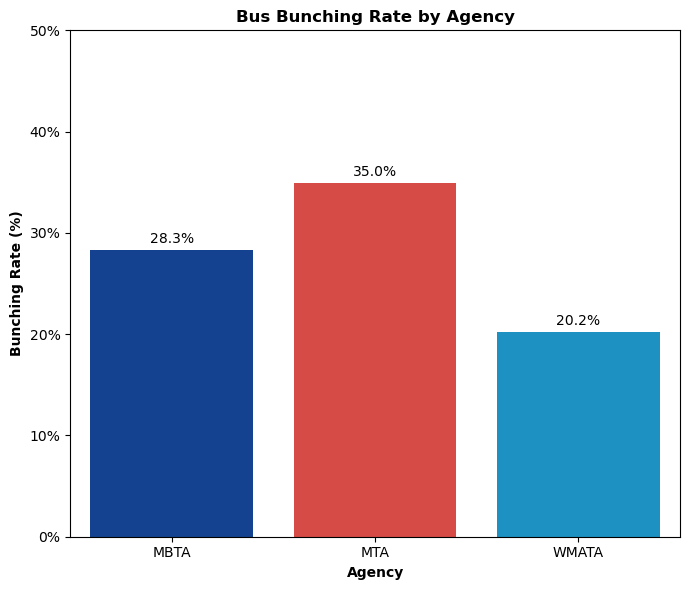

In [78]:
agency_colors = {'MBTA': '#003DA5', 'MTA': '#EE352E', 'WMATA': '#009CDE'}

fig, ax1 = plt.subplots(figsize=(7, 6))
sns.barplot(data=agency_bunching, x='Agency', y='Bunching Rate', ax=ax1, hue='Agency', palette=agency_colors, legend=False)

ax1.set_title('Bus Bunching Rate by Agency', fontweight='bold')
ax1.set_xlabel('Agency', fontweight='bold')
ax1.set_ylabel('Bunching Rate (%)', fontweight='bold')
ax1.set_ylim(0, 50)

ax1.set_yticks(ax1.get_yticks())
ax1.set_yticklabels([f'{int(x)}%' for x in ax1.get_yticks()]) # adding % after values on y axis
for container in ax1.containers: # adding bunching rate % over bars (needs to be in a loop if using hue)
    ax1.bar_label(container, fmt='%.1f%%', padding=3)

plt.tight_layout()
plt.savefig(path2 + 'agencybunchingrate_graph.png', dpi=300, bbox_inches='tight')
plt.show()

### Conclusions:
MTA shows the highest bunching rate at 35%, followed by MBTA at 28.3% and WMATA at 20.2%. Suggesting there is meaningful variation in bus reliability across agencies, with NYC experiencing the most frequent bunching despite operating in a similar dense urban environment to Boston.

In [28]:
headway_bunching = df.groupby(['agency', 'headway_bucket'], observed=True)['bunching'].mean().reset_index()
headway_bunching.columns = ['Agency', 'Headway', 'Bunching Rate']
headway_bunching['Bunching Rate'] = headway_bunching['Bunching Rate'] * 100
headway_bunching

,Agency,Headway,Bunching Rate
0,MBTA,10-20min,15.073758
1,MBTA,20-30min,5.489555
2,MBTA,30+min,1.559140
3,MBTA,<10min,36.252405
4,MTA,10-20min,16.748565
5,MTA,20-30min,8.541201
6,MTA,30+min,4.709558
7,MTA,<10min,44.873942
8,WMATA,10-20min,16.310883
9,WMATA,20-30min,3.809195


In [29]:
headway_bunching['Headway'] = pd.Categorical(headway_bunching['Headway'], 
                                              categories=['<10min', '10-20min', '20-30min', '30+min'], 
                                              ordered=True)
headway_bunching = headway_bunching.sort_values('Headway')
headway_bunching

,Agency,Headway,Bunching Rate
3,MBTA,<10min,36.252405
7,MTA,<10min,44.873942
11,WMATA,<10min,36.413230
0,MBTA,10-20min,15.073758
4,MTA,10-20min,16.748565
8,WMATA,10-20min,16.310883
1,MBTA,20-30min,5.489555
5,MTA,20-30min,8.541201
9,WMATA,20-30min,3.809195
2,MBTA,30+min,1.559140


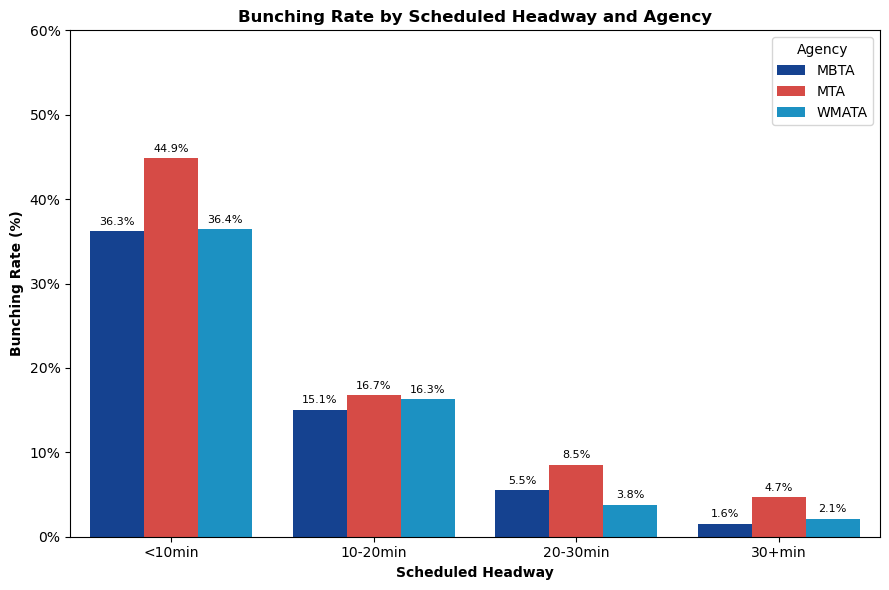

In [79]:
fig, ax2 = plt.subplots(figsize=(9, 6))
sns.barplot(data=headway_bunching, x='Headway', y='Bunching Rate', hue='Agency', 
            palette=agency_colors, ax=ax2)

ax2.set_title('Bunching Rate by Scheduled Headway and Agency', fontweight='bold')
ax2.set_xlabel('Scheduled Headway', fontweight='bold')
ax2.set_ylabel('Bunching Rate (%)', fontweight='bold')
ax2.set_ylim(0, 55)

ax2.set_yticks(ax2.get_yticks())
ax2.set_yticklabels([f'{int(x)}%' for x in ax2.get_yticks()])
ax2.legend(title='Agency')
for container in ax2.containers:
    ax2.bar_label(container, fmt='%.1f%%', padding=3, fontsize=8)

plt.tight_layout()
plt.savefig(path2 + 'headwaybunchingrate_graph.png', dpi=300, bbox_inches='tight')
plt.show()

### Conclusions:
Bunching rates drop dramatically as scheduled headway increases across all three agencies, from 36-45% on high frequency routes (<10 min) to just 1.6-4.7% on low frequency routes (30+ min). Showing there is a consistent inverse relationship across all three agencies suggests that headway frequency is a structural predictor of bunching regardless of city or transit system.

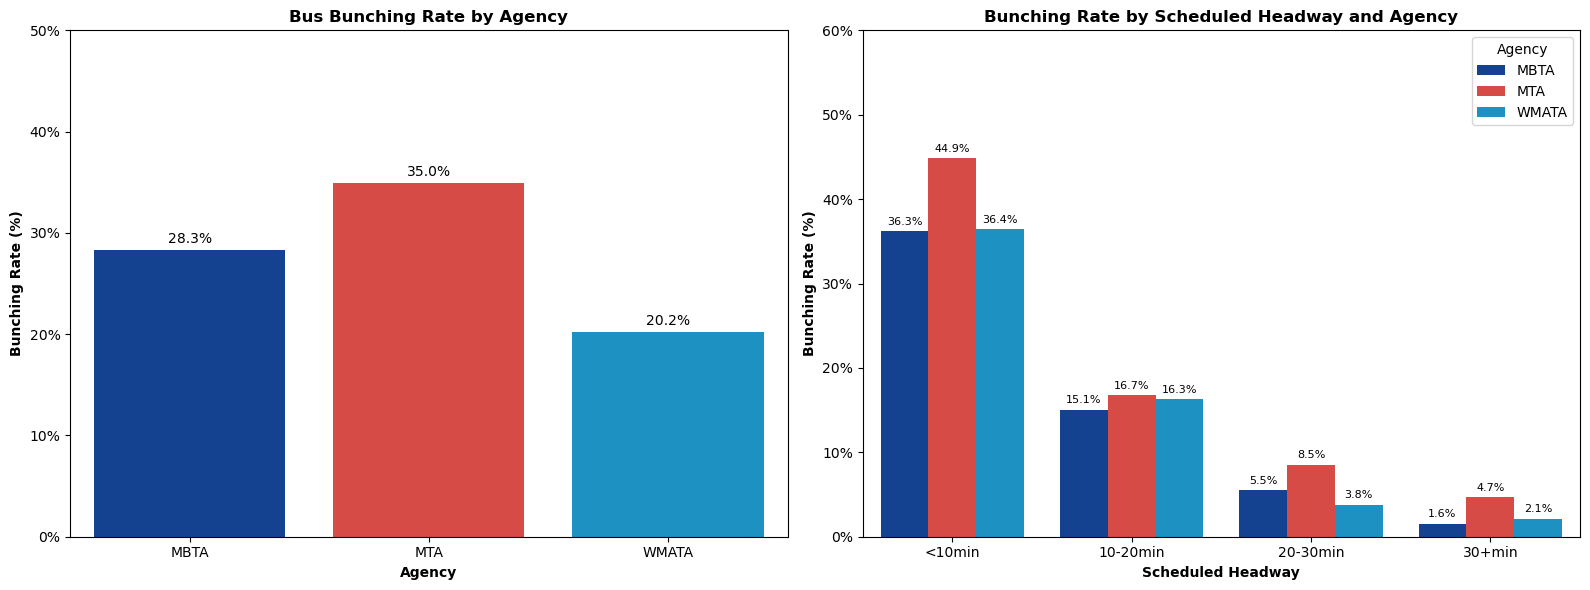

In [76]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Graph 1: Agency Bunching
sns.barplot(data=agency_bunching, x='Agency', y='Bunching Rate', ax=ax1, 
            hue='Agency', palette=agency_colors, legend=False)
ax1.set_title('Bus Bunching Rate by Agency', fontweight='bold')
ax1.set_xlabel('Agency', fontweight='bold')
ax1.set_ylabel('Bunching Rate (%)', fontweight='bold')
ax1.set_ylim(0, 50)
ax1.set_yticks(ax1.get_yticks())
ax1.set_yticklabels([f'{int(x)}%' for x in ax1.get_yticks()])
for container in ax1.containers:
    ax1.bar_label(container, fmt='%.1f%%', padding=3)

# Graph 2: Headway Bunching by Agency
sns.barplot(data=headway_bunching, x='Headway', y='Bunching Rate', hue='Agency', 
            palette=agency_colors, ax=ax2)
ax2.set_title('Bunching Rate by Scheduled Headway and Agency', fontweight='bold')
ax2.set_xlabel('Scheduled Headway', fontweight='bold')
ax2.set_ylabel('Bunching Rate (%)', fontweight='bold')
ax2.set_ylim(0, 60)
ax2.set_yticks(ax2.get_yticks())
ax2.set_yticklabels([f'{int(x)}%' for x in ax2.get_yticks()])
ax2.legend(title='Agency')
for container in ax2.containers:
    ax2.bar_label(container, fmt='%.1f%%', padding=3, fontsize=8)

plt.tight_layout()
plt.savefig(path2 + 'bunching_graphs.png', dpi=300, bbox_inches='tight')
plt.show()

<Axes: xlabel='agency', ylabel='deviation'>

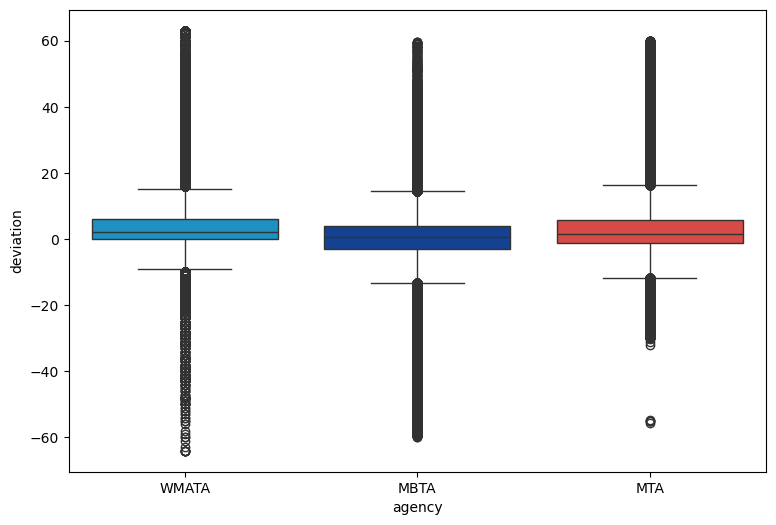

In [50]:
fig, ax3 = plt.subplots(figsize=(9, 6))

sns.boxplot(data=df, x='agency', y='deviation', hue='agency',
            palette=agency_colors, legend=False, ax=ax3)

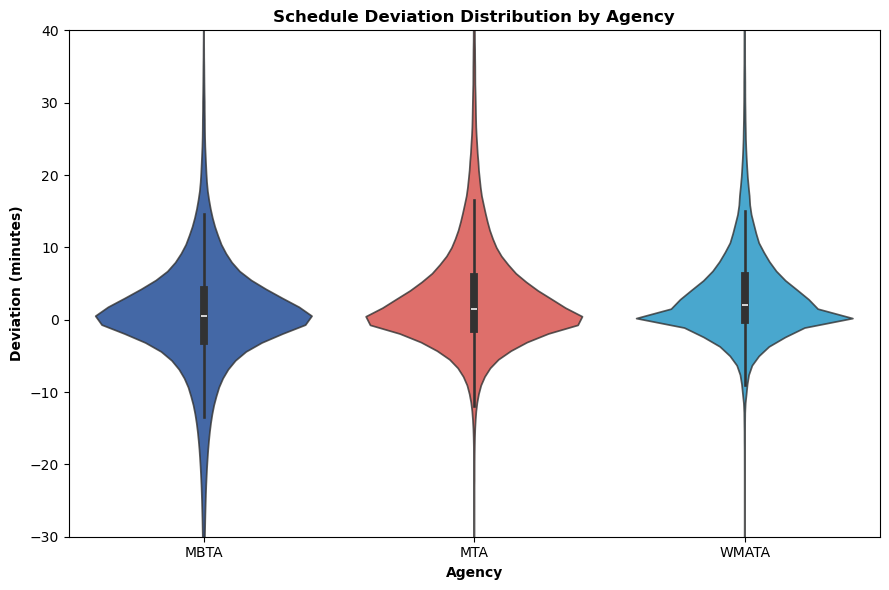

In [74]:
# trying out a violin plot since there are way too many outliers on boxplot
fig, ax4 = plt.subplots(figsize=(9, 6))

sns.violinplot(data=df, x='agency', y='deviation', hue='agency',
               palette=agency_colors, legend=False, ax=ax4, alpha=0.8, order=['MBTA', 'MTA', 'WMATA']) # alpha chnages transparency
ax4.set_ylim(-30, 40)
ax4.set_title('Schedule Deviation Distribution by Agency', fontweight='bold')
ax4.set_xlabel('Agency', fontweight='bold')
ax4.set_ylabel('Deviation (minutes)', fontweight='bold')

plt.tight_layout()
plt.savefig(path2 + 'scheduledeviation_graph.png', dpi=300, bbox_inches='tight')
plt.show()

### Conclusions:
- MBTA: Wider spread and extending further into negative territory meaning early buses (routes run ahead of schedule).
- MTA: The widest shape overall, bulges more on the positive side (meaning late), confirming MTA buses run the latest on average with the most variance
- WMATA: More narrow and shape centered just above 0, meaning most buses are close to on time with a relatively low variance; showing a much tighter distribution.

In [64]:
heatmap_data = df.groupby(['agency', 'day_of_week'])['bunching'].mean().unstack() * 100
heatmap_data.columns = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
heatmap_data

,Mon,Tue,Wed,Thu,Fri,Sat,Sun
agency,,,,,,,
MBTA,32.436993,31.323866,40.156288,37.540467,18.940641,19.825823,7.544317
MTA,35.184815,42.785860,43.439206,32.717616,33.450051,35.310590,21.663666
WMATA,14.224236,29.421776,24.356428,18.107004,25.590057,19.721756,12.469280


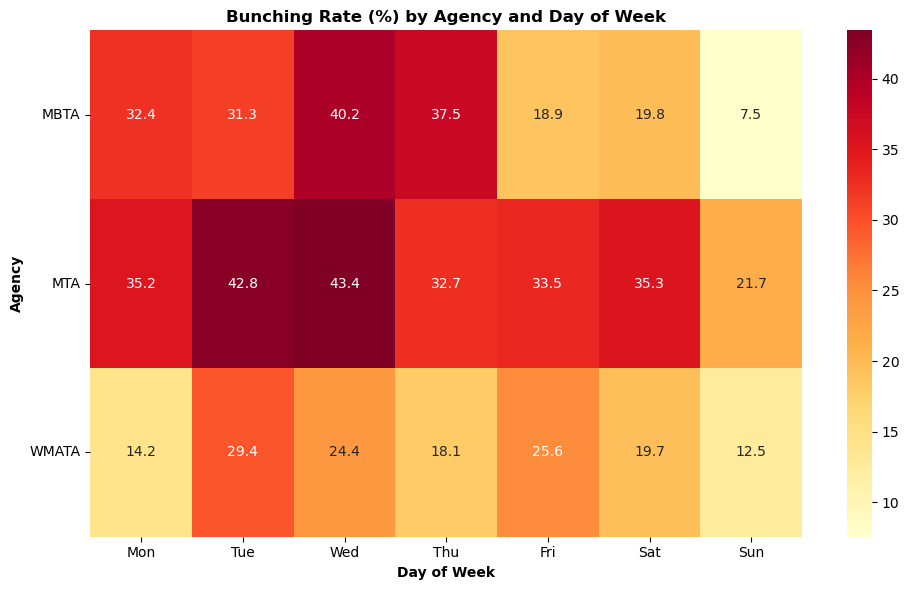

In [75]:
fig, ax5 = plt.subplots(figsize=(10, 6))
sns.heatmap(heatmap_data, annot=True, fmt='.1f', cmap='YlOrRd', ax=ax5)

ax5.set_title('Bunching Rate (%) by Agency and Day of Week', fontweight='bold')
ax5.set_xlabel('Day of Week', fontweight='bold')
ax5.set_ylabel('Agency', fontweight='bold')
ax5.set_yticks(ax5.get_yticks())
ax5.set_yticklabels(ax5.get_yticklabels(), rotation=0)

plt.tight_layout()
plt.savefig(path2 + 'daybunchingrate_graph.png', dpi=300, bbox_inches='tight')
plt.show()

### Conclusions:
- Sunday is consistently the best day across all agencies, lowest bunching for all three (MBTA 7.5%, MTA 21.7%, WMATA 12.5%)
- MTA: Tuesday/Wednesday are the worst (42.8%, 43.4%) — mid-week peak in NYC bunching
- MBTA: Wednesday/Thursday spike (40.2%, 37.5%) then drops sharply on Friday, this is a rather unusual pattern  
- WMATA: Most inconsistent, Monday is surprisingly low (14.2%) but Tuesday jumps to 29.4%. Possibly due to WFH?
- Friday is interesting, MBTA drops to 18.9% while MTA stays high at 33.5% and WMATA increases to 25.6%

## Resources:

https://stackoverflow.com/questions/63723514/userwarning-fixedformatter-should-only-be-used-together-with-fixedlocator
https://stackoverflow.com/questions/43214978/how-to-display-custom-values-on-a-bar-plot
https://stackoverflow.com/questions/39223256/pandas-dataframe-sort-by-categorical-column-but-by-specific-class-ordering

https://www.domo.com/learn/charts/violin-plots
https://seaborn.pydata.org/generated/seaborn.violinplot.html
https://www.geeksforgeeks.org/python/change-the-line-opacity-in-matplotlib/

Prof K
Great, can you include definitions of headway and deviation? What does that mean to the avg person?
Interesting that Tues and Wednesday has more delays

You will need to give context over the complexity of systems - the differences in how many, how long and how long buses run (I suspect mta is more complex and therefore faces more shcheduling issues)
grade: 100